In [1]:
from OOP_so_far import RunSSA, ModuleProperties, CombiningModules, plot_combined_conductance
from sympy import *
import numpy as np
import time

/Users/willalston/Desktop/Msci_Project/git_repos/students/Will/Gillespie_simulations/OOP_so_far.py:1076: SyntaxWarning: invalid escape sequence '\m'
  chem_pot = symbols(f"\mu_{species_symbol}")


# Define Module 

In [2]:
# MODULE 1


SM = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names = ["Ea", "EaS","EaS2","S","Na"]

num_internal_species = 3


# MODULE 2

SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["Eb", "EbF", "EbW", "Eb*", "Na", "Nb", "F", "W"]

num_internal_species2 = 4



# Prepare for simulation

In [3]:
# Use ModuleProperties to create module variables for our CRNs

module1_for_simulating = ModuleProperties(SM, 3, species_names)

module2_for_simulating = ModuleProperties(SM2, 4, species_names2)


# Define the initial conditions we need to simulate our CRNs using the SSA

simulation_length = 400.0

burn_in_time = 100.0 # This quantity is important for ensuring we are sampling the steady state - it is best to first pick any value
                     # burn_in_time < simulation_length, visually see where the transient state ends on the counts plot, and then
                     # adjust this value appropriately for sampling runs.

initial_counts = [350, 350, 350, 50, 50]

rates = 0.1* np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])



initial_counts2 = [350, 350, 350, 350, 50, 50, 50, 50]

rates2 = 0.1 * np.array([0.01, 1.0, 1.0, 0.5, 1.5, 0.01, 0.01, 1.0, 1.2, 0.01])

# Create simulation module variables

SIM1 = RunSSA(module1_for_simulating, initial_counts, rates, simulation_length, burn_in_time)

SIM2 = RunSSA(module2_for_simulating, initial_counts2, rates2, simulation_length, burn_in_time)



# Plot species population trajectories over time

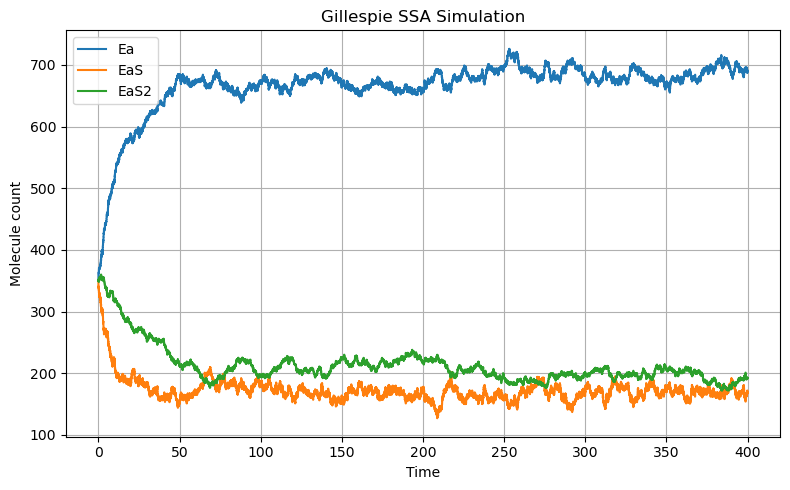

In [11]:
# 1) Change store_trajectories = False (default = True) to skip trajectory plotting. This offers up to 100x speed up.
#
# 2) Add an explicit set of starting populations as a list (in same order as 'species_names' used in ModuleProperties),
#    default is to use pre-defined list 'initial_counts' in RunSSA.

SIM1.run_SSA_and_plot_counts(store_trajectories=True, starting_pops=None)

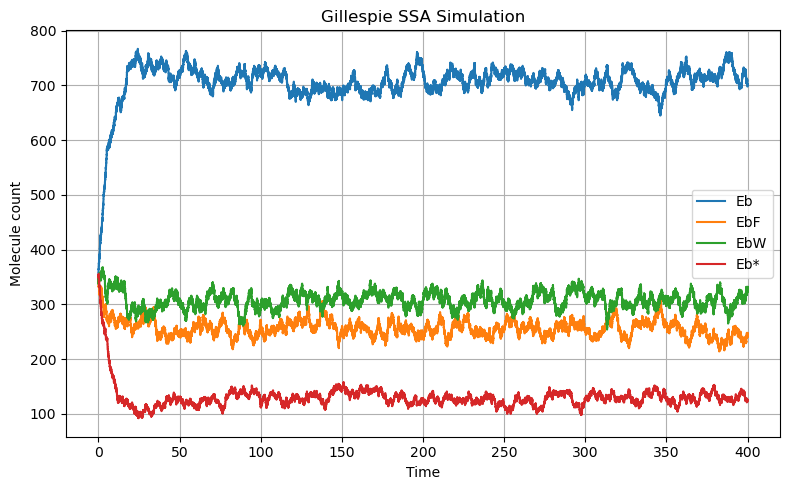

In [9]:
SIM2.run_SSA_and_plot_counts(True)

# Plot the distribution of currents and forces over a set number of iterations 

In [27]:
# This attribute allows us to see how well the currents and forces converge to a Gaussian for a different number of SSA repeats. The plotted data is time averaged current and force across all
# the reactions in the CRN after each individual run of SSA (out of num_iterations). This is helpful for determining how many iterations we should run
# when we want to average these values. The default values are bins=50, num_iterations = 50, Gaussian_points = 1000. Reactions are in order of the columns of the inputted stoichiometric matrix.

SIM1.plot_gaussian_comparison(bins=50, num_iterations=2000, Gaussian_points=1000)


SystemError: CPUDispatcher(<function ssa_core at 0x112551c60>) returned a result with an exception set

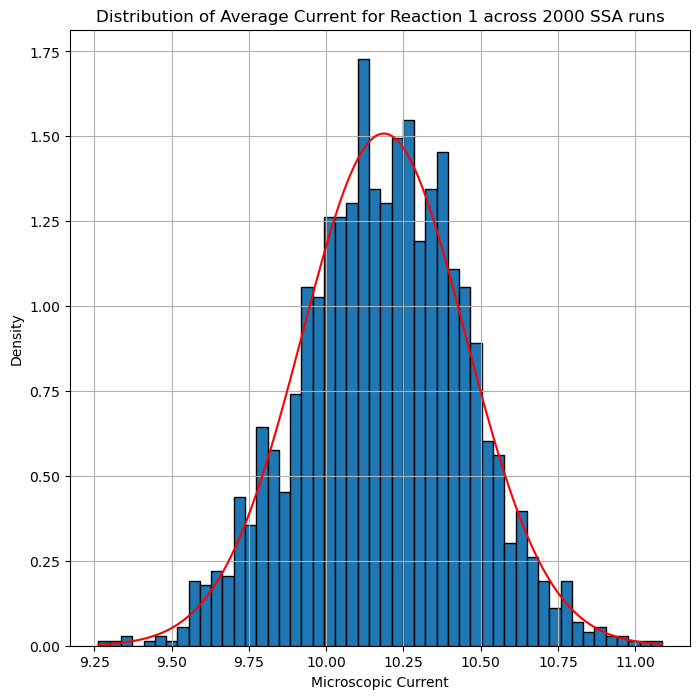

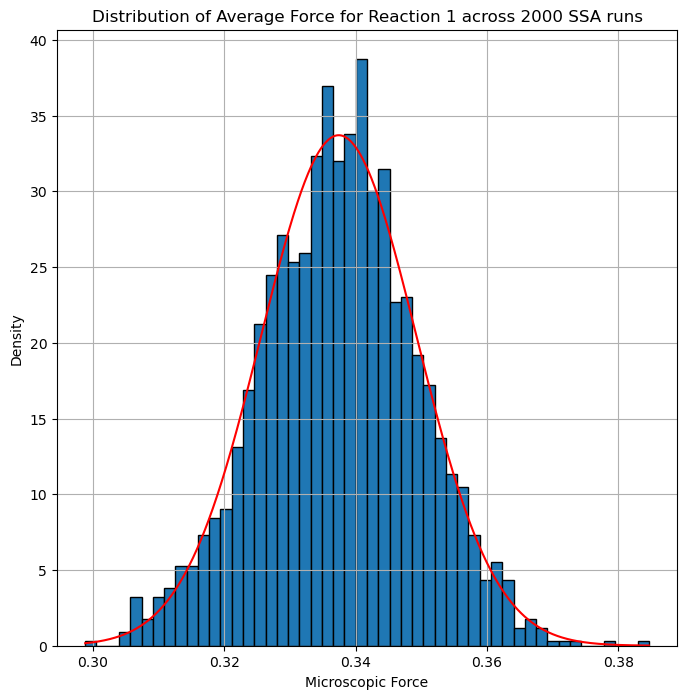

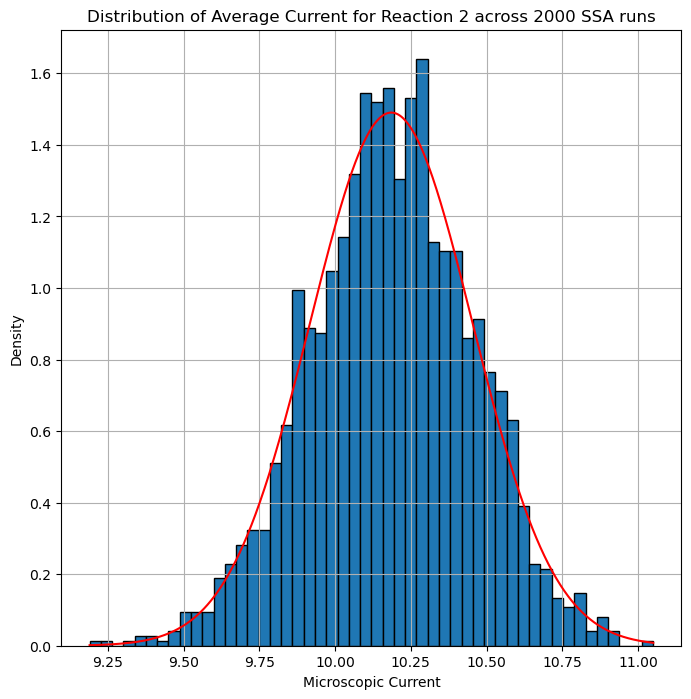

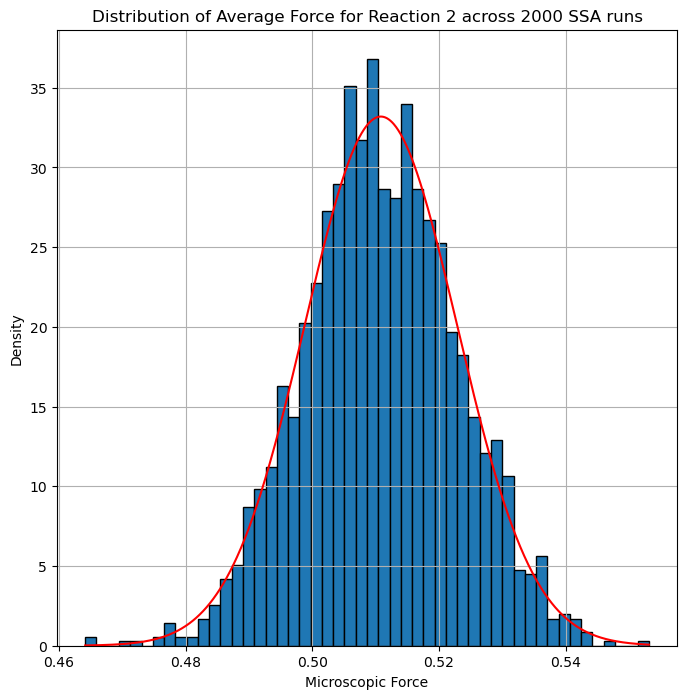

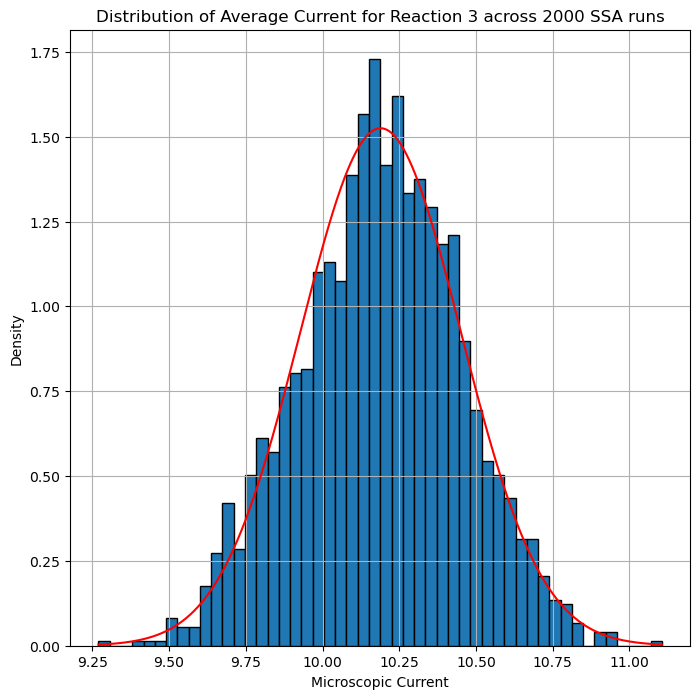

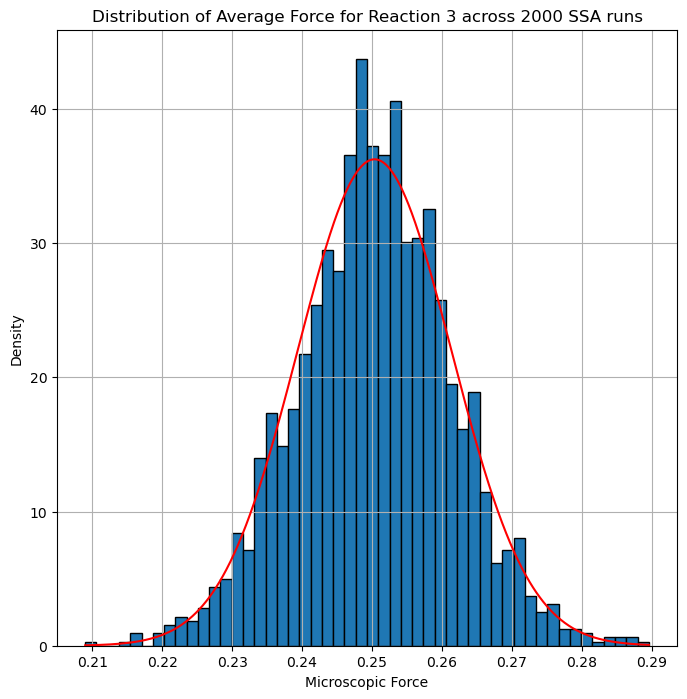

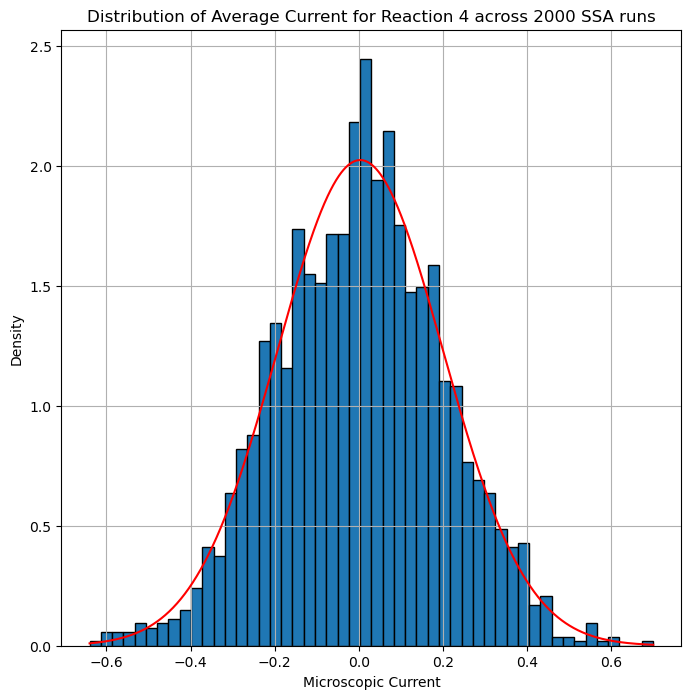

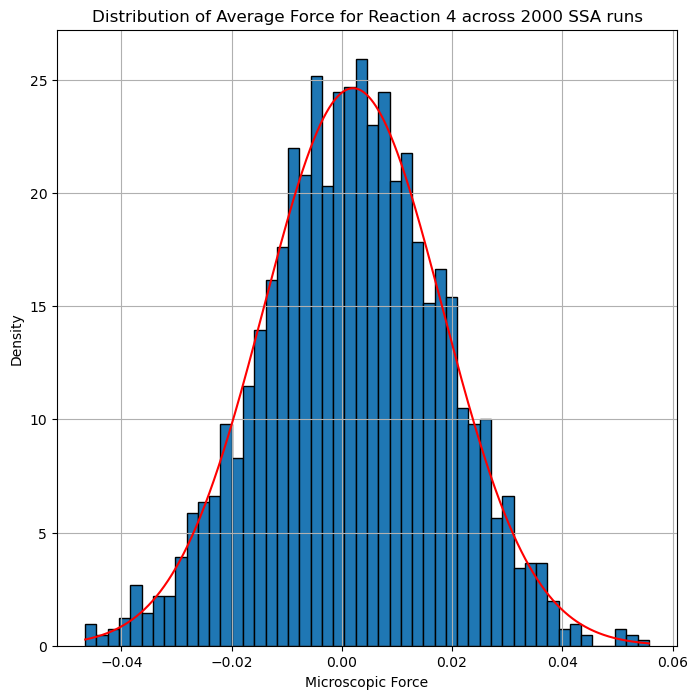

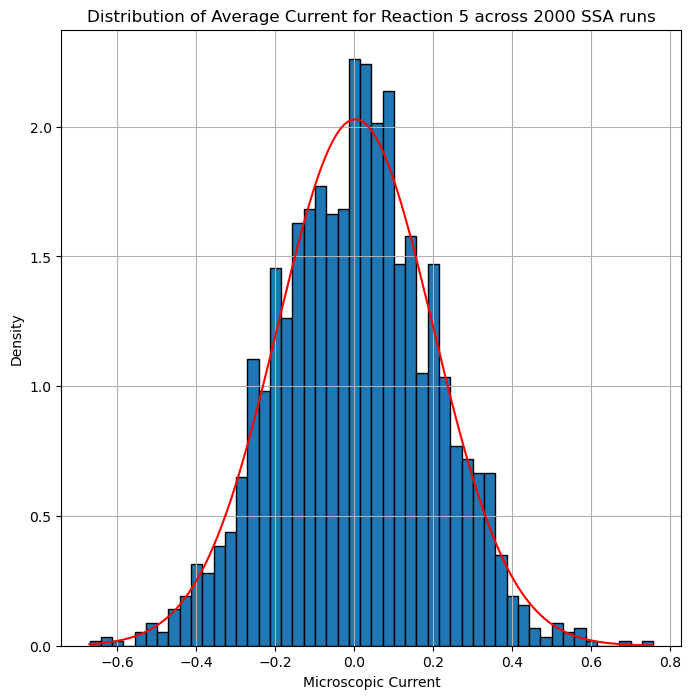

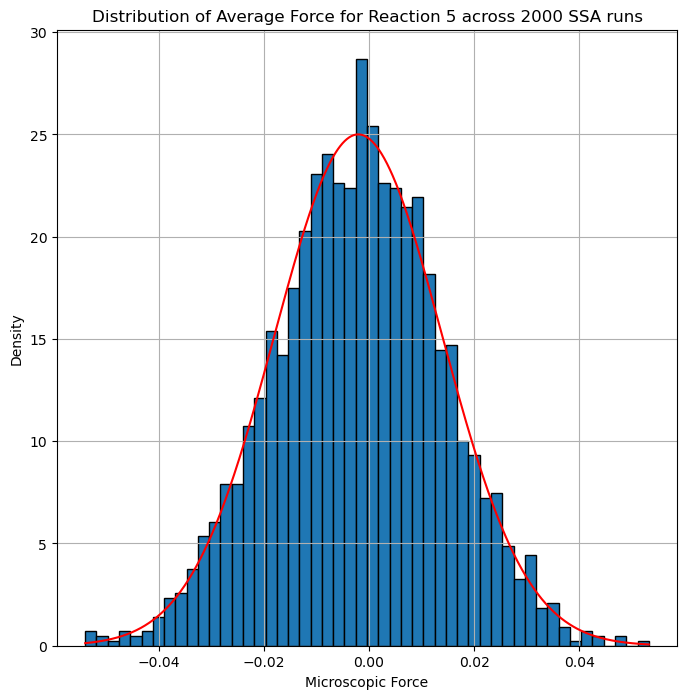

In [ ]:
SIM2.plot_gaussian_comparison(bins=50, num_iterations=2000, Gaussian_points=1000)

# Create I-F curves for the reactions in the module for a varied initial species count

## Compute I-F data from simulation

In [8]:
# Run SSA sweeps over a varying initial count. In this line, we vary the species at position 3 in species_names ('S') with integer 
# values between 50 and 500, running 40 iterations for each value of 'S'. We opt for 'verbose=True' so that we might track the progress
# through the various 'S' values. The 'covariance_reaction_indicies' tells the code which currents to sample the covariance between,
# this should be the set of currents in the fundamental current vector. For module 1, I = j1, so we set this = [0]. For module 2,
# I_ = (j3, j5) so we choose = [2, 4].

# Module 1

SIM1.run_IF_sweep(
    
        species_index=3,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=10, 
        covariance_reaction_indices=[0],   
        verbose=True)


Sweep 1/50  (Varying Species: [S] = 50)
Sweep 2/50  (Varying Species: [S] = 59)
Sweep 3/50  (Varying Species: [S] = 68)
Sweep 4/50  (Varying Species: [S] = 77)
Sweep 5/50  (Varying Species: [S] = 86)
Sweep 6/50  (Varying Species: [S] = 95)
Sweep 7/50  (Varying Species: [S] = 105)
Sweep 8/50  (Varying Species: [S] = 114)
Sweep 9/50  (Varying Species: [S] = 123)
Sweep 10/50  (Varying Species: [S] = 132)
Sweep 11/50  (Varying Species: [S] = 141)
Sweep 12/50  (Varying Species: [S] = 151)
Sweep 13/50  (Varying Species: [S] = 160)
Sweep 14/50  (Varying Species: [S] = 169)
Sweep 15/50  (Varying Species: [S] = 178)
Sweep 16/50  (Varying Species: [S] = 187)
Sweep 17/50  (Varying Species: [S] = 196)
Sweep 18/50  (Varying Species: [S] = 206)
Sweep 19/50  (Varying Species: [S] = 215)
Sweep 20/50  (Varying Species: [S] = 224)
Sweep 21/50  (Varying Species: [S] = 233)
Sweep 22/50  (Varying Species: [S] = 242)
Sweep 23/50  (Varying Species: [S] = 252)
Sweep 24/50  (Varying Species: [S] = 261)
Sweep 2

(array([[ 4.14324325e+00,  4.19324216e+00, -9.66645650e-02],
        [ 4.42984706e+00,  4.45984602e+00, -3.33321825e-03],
        [ 4.23315501e+00,  4.24315459e+00, -2.99987363e-02],
        [ 4.05331556e+00,  4.03664897e+00,  5.66664182e-02],
        [ 4.06997704e+00,  4.01331070e+00, -9.99994359e-03],
        [ 4.01327689e+00,  4.03660989e+00, -4.33327239e-02],
        [ 4.39666361e+00,  4.36333030e+00,  7.33332823e-02],
        [ 4.16297151e+00,  4.20630107e+00, -1.99982618e-02],
        [ 4.22329584e+00,  4.21996254e+00, -2.99997337e-02],
        [ 4.03328482e+00,  4.05328458e+00, -8.33323310e-02]]),
 array([[ 4.83268648e-01,  2.44792510e+00,  3.85165983e-03],
        [ 5.35665624e-01,  2.39552813e+00,  3.76213738e-03],
        [ 5.42392042e-01,  2.38880171e+00, -1.72431353e-02],
        [ 4.97122997e-01,  2.43407076e+00, -2.59874819e-02],
        [ 4.97684691e-01,  2.43350906e+00, -1.35938838e-02],
        [ 4.79500829e-01,  2.45169292e+00, -2.15064722e-02],
        [ 5.27202943e-

In [ ]:
# Module 2

SIM2.run_IF_sweep(
    
        species_index=4,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=250, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

Sweep 1/50  (species[Na] = 50)
Sweep 2/50  (species[Na] = 59)
Sweep 3/50  (species[Na] = 68)
Sweep 4/50  (species[Na] = 77)
Sweep 5/50  (species[Na] = 86)
Sweep 6/50  (species[Na] = 95)
Sweep 7/50  (species[Na] = 105)
Sweep 8/50  (species[Na] = 114)
Sweep 9/50  (species[Na] = 123)
Sweep 10/50  (species[Na] = 132)
Sweep 11/50  (species[Na] = 141)
Sweep 12/50  (species[Na] = 151)
Sweep 13/50  (species[Na] = 160)
Sweep 14/50  (species[Na] = 169)
Sweep 15/50  (species[Na] = 178)
Sweep 16/50  (species[Na] = 187)
Sweep 17/50  (species[Na] = 196)
Sweep 18/50  (species[Na] = 206)
Sweep 19/50  (species[Na] = 215)
Sweep 20/50  (species[Na] = 224)
Sweep 21/50  (species[Na] = 233)
Sweep 22/50  (species[Na] = 242)
Sweep 23/50  (species[Na] = 252)
Sweep 24/50  (species[Na] = 261)
Sweep 25/50  (species[Na] = 270)
Sweep 26/50  (species[Na] = 279)
Sweep 27/50  (species[Na] = 288)
Sweep 28/50  (species[Na] = 297)
Sweep 29/50  (species[Na] = 307)
Sweep 30/50  (species[Na] = 316)
Sweep 31/50  (species[Na]

## Plot the curves

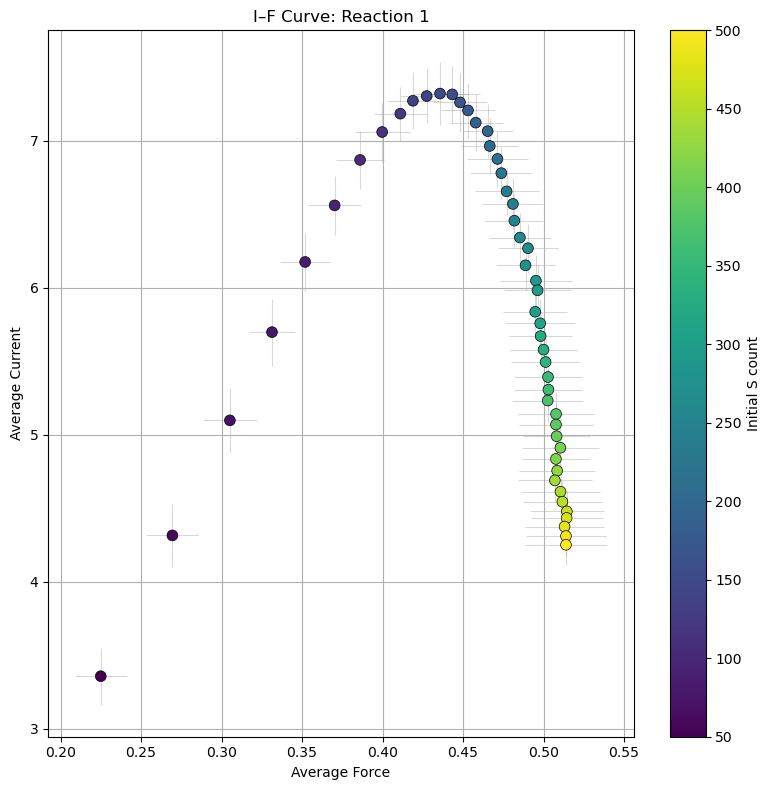

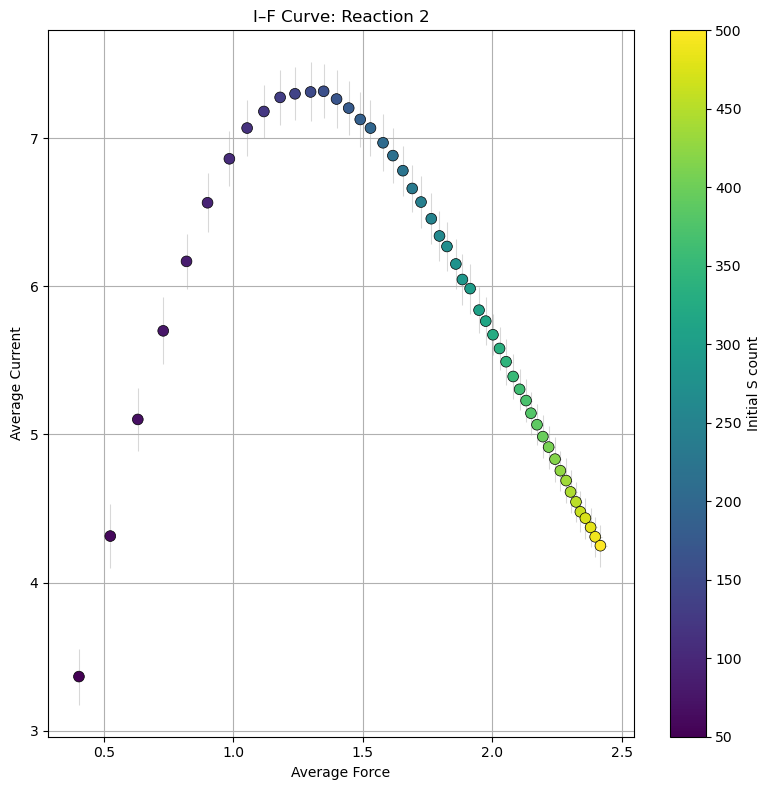

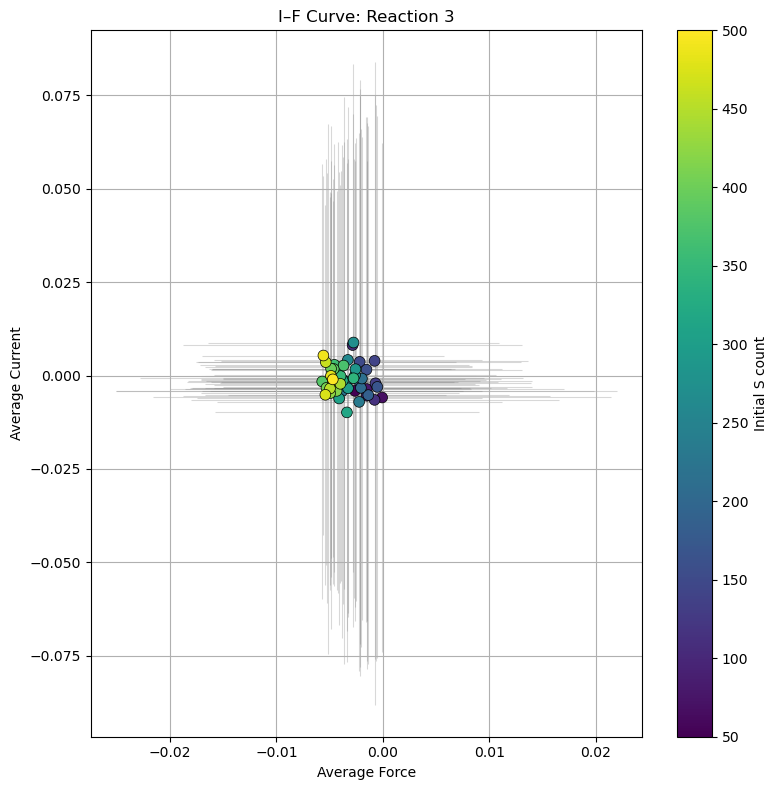

In [ ]:
# Now, we can plot the resulting I-F curves. We can select which to plot with 'reaction_indices', note that 'reaction 1' has index 0.
# Default is to plot all reactions. We can opt to plot any analytical results we may have calculated by passing these as lists into
# 'analytical_currents' and 'analytical_forces'.

# Module 1

SIM1.plot_IF_curves(

        reaction_indices=None,
        analytical_currents=None,
        analytical_forces=None,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    )

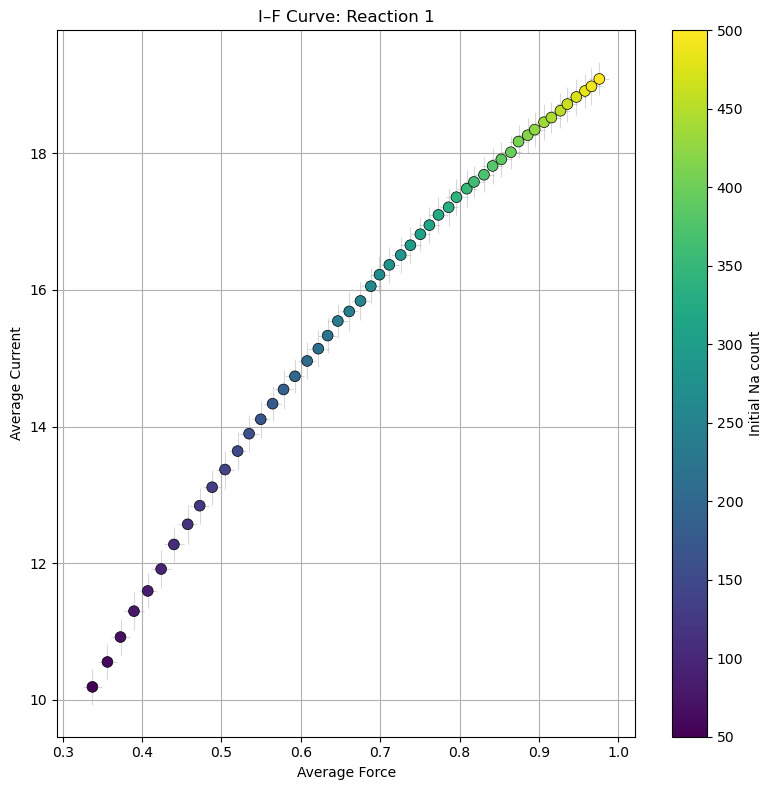

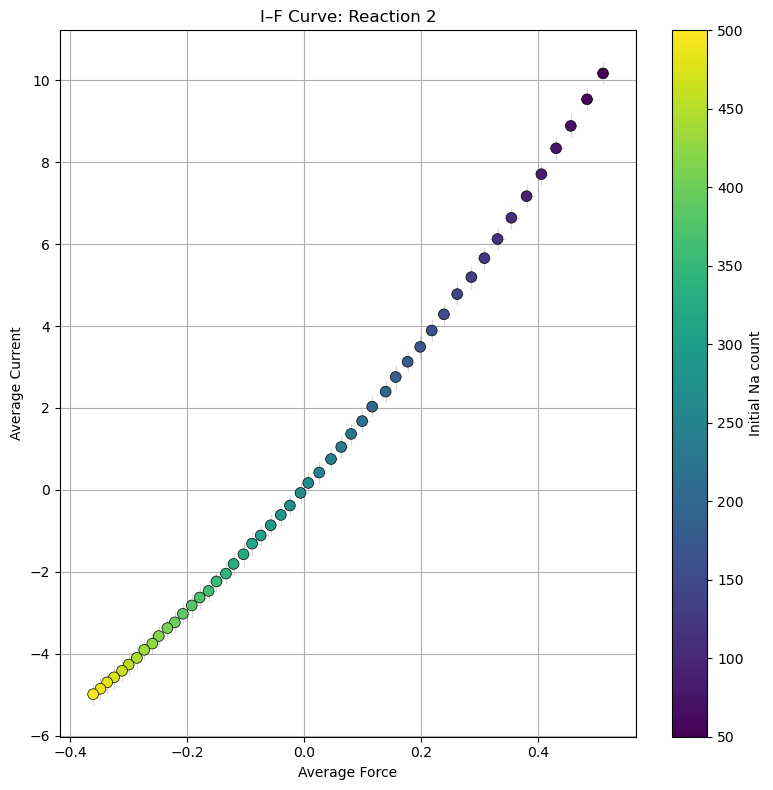

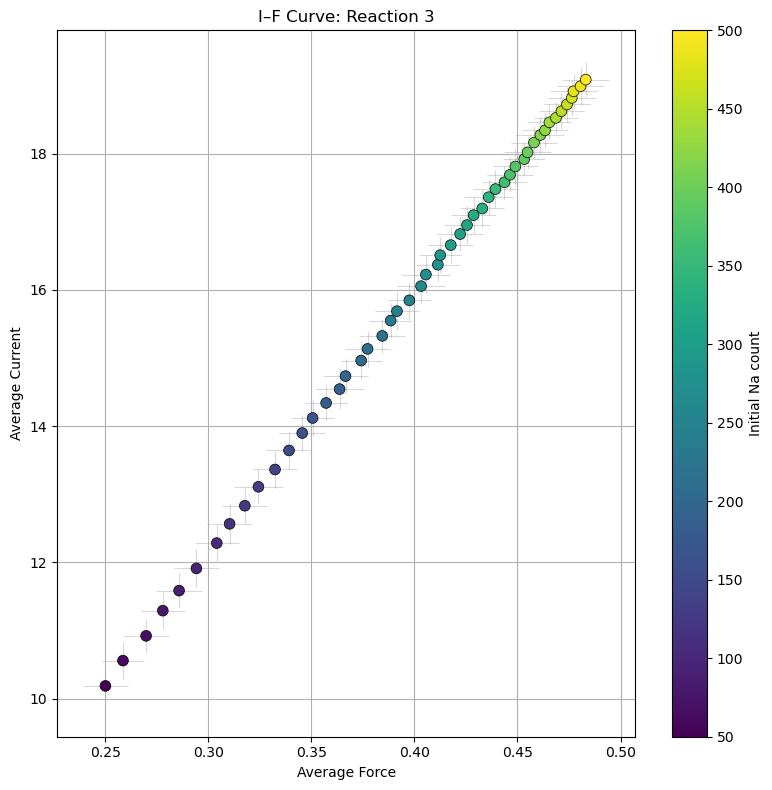

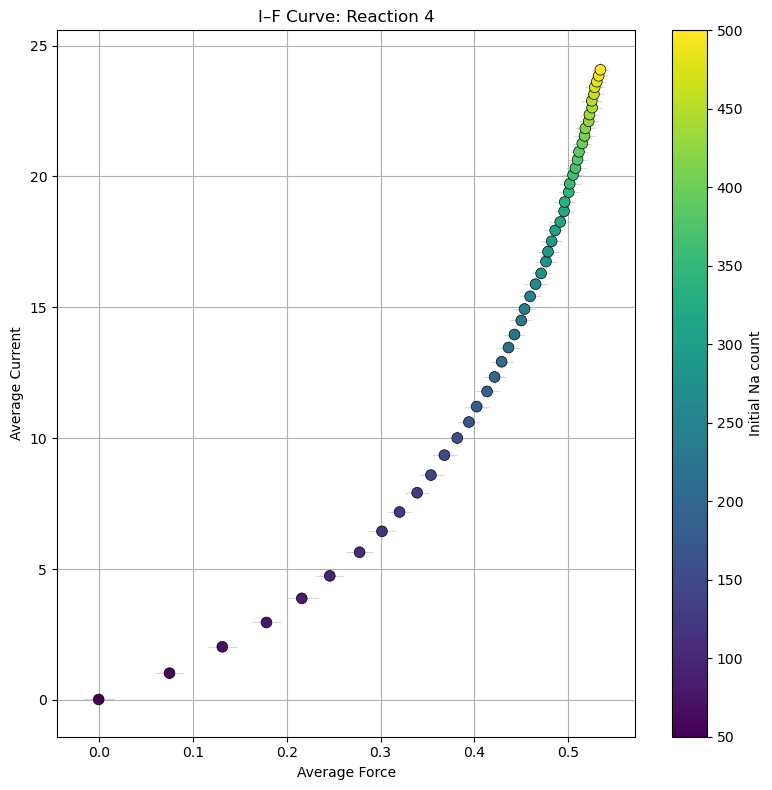

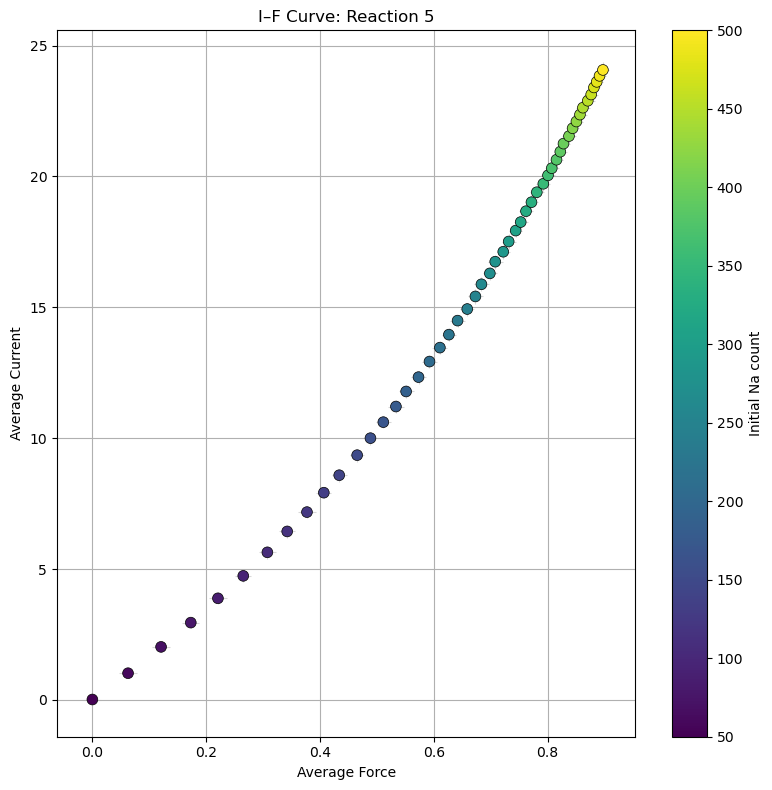

In [ ]:
# Module 2

SIM2.plot_IF_curves(

        reaction_indices=None,
        analytical_currents=None,
        analytical_forces=None,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    )

# Calculate and plot scalar or eigenvalues of conductance for inividual CRNs

In [ ]:
# Calculate conductance of our individual CRNs. Again, we can opt to plot any analytical results for the conductance by passing the 
# currents and forces as lists into 'analytical_currents' and 'analytical_forces'.

SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

In [ ]:
SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

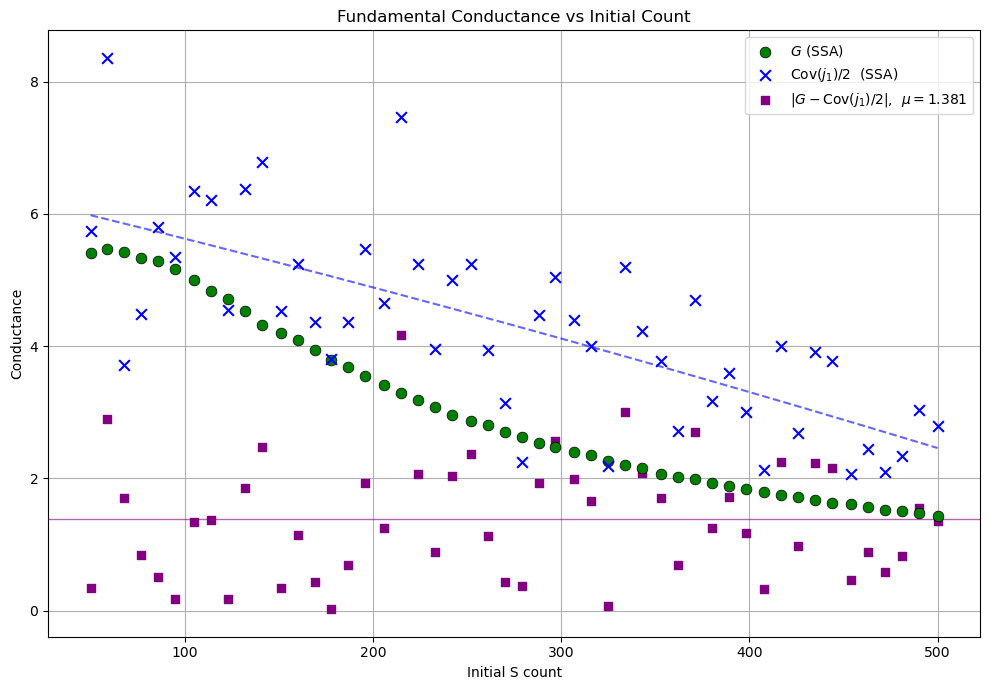

In [ ]:
# Plot the conductances. For module 1, we expect a scalar value, so the code will plot this scalar conductance vs the count values.
# We can opt to plot the covariance of the currents and forces with 'show_covariance=True', this plots Cov(I)/2. Also, we can plot
# the difference between the numerical and analytical conductances with 'show_difference=True', this plots the value |G - Cov(I)/2|. 
# We can also fit a polynomial of order 'fit_order' to the numerical conductance values.

# Module 1

SIM1.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )

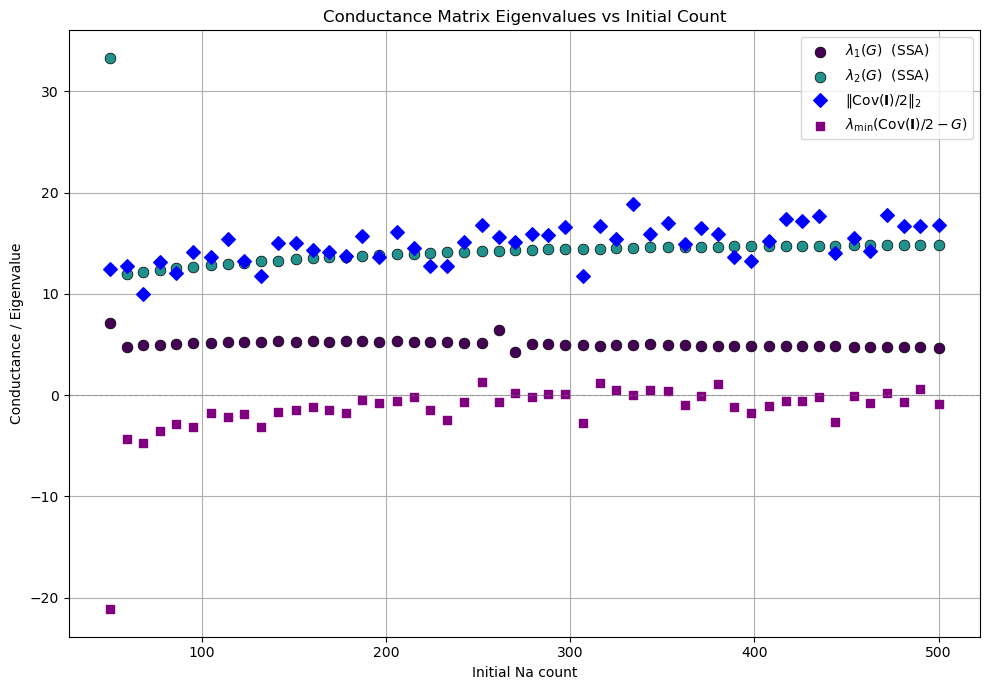

In [ ]:
# The code automatically detects whether the conductance is scalar or a matrix.

# Module 2

SIM2.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )

# Numerical Conductance of Serially Connected CRNs

In [ ]:
# First, create the following module variables for the two CRNs we want to combine.

module1_for_simulating = ModuleProperties(SM, 3, species_names)

module2_for_simulating = ModuleProperties(SM2, 4, species_names2)

# We must create the individual resistance matrices for each module before combining them

module1_for_simulating.calculate_fundamental_resistance_matrix() 

module2_for_simulating.calculate_fundamental_resistance_matrix()

# Then prepare the module variables for simulation

SIM1 = RunSSA(module1_for_simulating, initial_counts, rates, simulation_length, burn_in_time)

SIM2 = RunSSA(module2_for_simulating, initial_counts2, rates2, simulation_length, burn_in_time)



In [11]:
# Compute data that will be combined. Here vary Na over the same values in both (the overlapping species).

# Module 1

SIM1.run_IF_sweep(
    
        species_index=4,
        count_values=np.linspace(50,500,60,dtype='int'),
        total_iterations=10, 
        covariance_reaction_indices=[0],   
        verbose=True)

# Module 2

SIM2.run_IF_sweep(
    
        species_index=4,
        count_values=np.linspace(50,500,60,dtype='int'),
        total_iterations=10, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

Sweep 1/60  (Varying Species: [Na] = 50)
Sweep 2/60  (Varying Species: [Na] = 57)
Sweep 3/60  (Varying Species: [Na] = 65)
Sweep 4/60  (Varying Species: [Na] = 72)
Sweep 5/60  (Varying Species: [Na] = 80)
Sweep 6/60  (Varying Species: [Na] = 88)
Sweep 7/60  (Varying Species: [Na] = 95)
Sweep 8/60  (Varying Species: [Na] = 103)
Sweep 9/60  (Varying Species: [Na] = 111)
Sweep 10/60  (Varying Species: [Na] = 118)
Sweep 11/60  (Varying Species: [Na] = 126)
Sweep 12/60  (Varying Species: [Na] = 133)
Sweep 13/60  (Varying Species: [Na] = 141)
Sweep 14/60  (Varying Species: [Na] = 149)
Sweep 15/60  (Varying Species: [Na] = 156)
Sweep 16/60  (Varying Species: [Na] = 164)
Sweep 17/60  (Varying Species: [Na] = 172)
Sweep 18/60  (Varying Species: [Na] = 179)
Sweep 19/60  (Varying Species: [Na] = 187)
Sweep 20/60  (Varying Species: [Na] = 194)
Sweep 21/60  (Varying Species: [Na] = 202)
Sweep 22/60  (Varying Species: [Na] = 210)
Sweep 23/60  (Varying Species: [Na] = 217)
Sweep 24/60  (Varying Speci

(array([[18.92656768, -4.97997396, 18.929901  , 23.98654122, 23.98987454],
        [19.16980478, -4.53995377, 19.21647097, 23.74309154, 23.78975773],
        [18.93304883, -5.0932568 , 18.87638302, 24.0329722 , 23.89964087],
        [19.08998029, -5.21666128, 19.10664694, 24.2766416 , 24.23997497],
        [19.43304575, -4.94326018, 19.47971172, 24.41297205, 24.46963788],
        [18.84642823, -4.90660459, 18.88976101, 23.79303231, 23.84969826],
        [19.05991522, -5.10664395, 18.95658235, 24.15989254, 24.09655948],
        [18.99316897, -4.8266249 , 18.99316897, 23.85979352, 23.88979326],
        [19.08657806, -4.78664445, 19.0565782 , 23.87322251, 23.91322232],
        [19.51986319, -5.3499625 , 19.44653037, 24.85649245, 24.86315907]]),
 array([[ 1.00173238, -0.37877972,  0.47565963,  0.53886584,  0.87411391],
        [ 0.97518964, -0.36353125,  0.4869539 ,  0.53055813,  0.89767009],
        [ 0.99080533, -0.37159023,  0.47939719,  0.53466768,  0.88550155],
        [ 0.98412378, -

In [ ]:
# Compute lists of the numerical conductance for each module, we will not overlay any analytical results.

module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

In [10]:
# Now we use the CombiningModules class to combine the data from the two modules, this essentially involves replacing the symbolic
# values of resistance with the numerical results calculated above, and the same code as the symbolic case follows.

module3 = CombiningModules(module1_for_simulating, module2_for_simulating, module1_conductances, module2_conductances)

# Store the numerical combined condictance matrices

combined_Gs = module3.numerical_combined_fundamental_CMs# Acquire the serially combined conductance matrix

NameError: name 'module1_conductances' is not defined

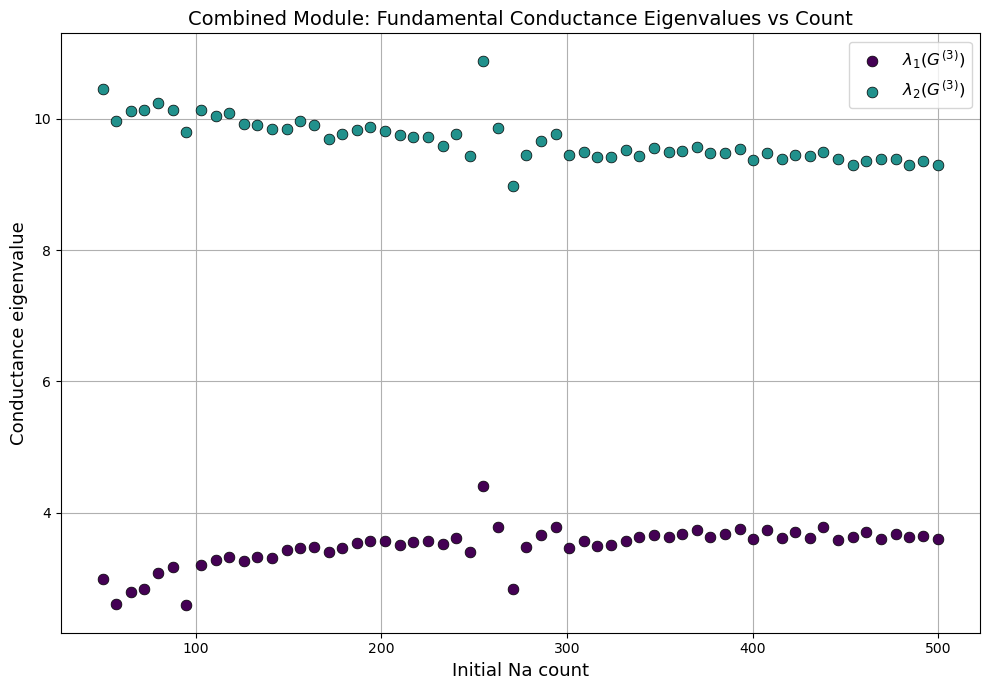

In [15]:
# Use a dedicated function to plot this combined conductance. It is important to include the same count_values as the
# compute_conductances attribute used, and include the species label that is being varied. If the combined_Gs is scalar, this will
# plot a simple line of conductance vs count, if it is a list of matrices, this will plot the eigenvalues of these matrices.

plot_combined_conductance(
    combined_CMs  = combined_Gs,
    count_values  = np.linspace(50, 500, 60, dtype='int'),
    species_label ='Na' 
)

### Plotting the conductance directly from the joint SM

In [4]:
# module3 = CombiningModules(module1_for_simulating, module2_for_simulating)
# module3.stoich_matrix

m1 = ModuleProperties(SM, 3, species_names)

m1.calculate_fundamental_resistance_matrix()

m2 = ModuleProperties(SM2, 4, species_names2)

m2.calculate_fundamental_resistance_matrix()

⎡r₂ + r₄ + r₅      -r₂     ⎤
⎢                          ⎥
⎣    -r₂       r₁ + r₂ + r₃⎦

In [5]:
m3 = CombiningModules(m1,m2,None,None) # order matters! Require Left feeds into Right

module3_for_simulating = ModuleProperties(m3.stoich_matrix, m3.num_internal_species, m3.species_names)

In [6]:
# Build dictionary of counts: names

left_counts_dict  = dict(zip(module1_for_simulating.species_names, initial_counts))
right_counts_dict = dict(zip(module2_for_simulating.species_names, initial_counts2))

# Create combined rates and counts

combined_initial_counts, combined_rates = m3.build_combined_initial_counts_and_rates(
    left_initial_counts  = left_counts_dict,
    right_initial_counts = right_counts_dict,
    left_rates = rates,
    right_rates = rates2
)


=== Overlapping species detected ===
  ['Na']
These species appear in both modules and are now internal.
Please enter a single initial count for each:

  Species 'Na':
    Left  module value : 50
    Right module value : 50

=== Combined initial counts ===
  [0] Ea           : 350
  [1] EaS          : 350
  [2] EaS2         : 350
  [3] Na           : 50.0 ← user entered
  [4] Eb           : 350
  [5] EbF          : 350
  [6] EbW          : 350
  [7] Eb*          : 350
  [8] S            : 50
  [9] Nb           : 50
  [10] F            : 50
  [11] W            : 50

=== Combined rates ===
  Reaction  1 (left ) : k+ = 0.0005,  k- = 0.08
  Reaction  2 (left ) : k+ = 0.06,  k- = 0.0002
  Reaction  3 (left ) : k+ = 0.0012,  k- = 0.05
  Reaction  4 (right) : k+ = 0.001,  k- = 0.1
  Reaction  5 (right) : k+ = 0.1,  k- = 0.05
  Reaction  6 (right) : k+ = 0.15,  k- = 0.001
  Reaction  7 (right) : k+ = 0.001,  k- = 0.1
  Reaction  8 (right) : k+ = 0.12,  k- = 0.001


In [7]:
# Create simulation module variable

SIM3 = RunSSA(module3_for_simulating, combined_initial_counts, combined_rates, 400, 100)

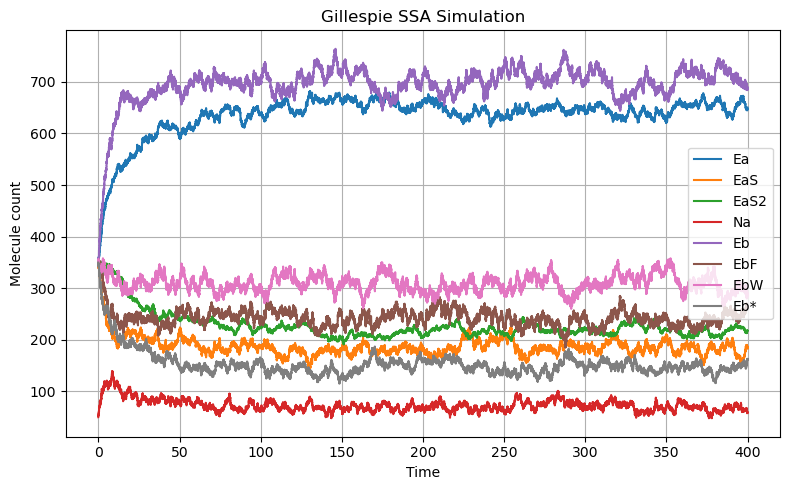

In [ ]:
# We can plot the combined module

SIM3.run_SSA_and_plot_counts(store_trajectories=True, starting_pops=None)

In [13]:
# And again run the sim over many values of a specified species to see the conductance changes (let's try 'Na', as it is an external 
# species. This is index = 3. And lets ignore covariance for now

# Run the sweep

SIM3.run_IF_sweep(
    
        species_index=3,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=10, 
        covariance_reaction_indices=None,   
        verbose=True)




Sweep 1/50  (Varying Species: [Na] = 50)
Sweep 2/50  (Varying Species: [Na] = 59)
Sweep 3/50  (Varying Species: [Na] = 68)
Sweep 4/50  (Varying Species: [Na] = 77)
Sweep 5/50  (Varying Species: [Na] = 86)
Sweep 6/50  (Varying Species: [Na] = 95)
Sweep 7/50  (Varying Species: [Na] = 105)
Sweep 8/50  (Varying Species: [Na] = 114)
Sweep 9/50  (Varying Species: [Na] = 123)
Sweep 10/50  (Varying Species: [Na] = 132)
Sweep 11/50  (Varying Species: [Na] = 141)
Sweep 12/50  (Varying Species: [Na] = 151)
Sweep 13/50  (Varying Species: [Na] = 160)
Sweep 14/50  (Varying Species: [Na] = 169)
Sweep 15/50  (Varying Species: [Na] = 178)
Sweep 16/50  (Varying Species: [Na] = 187)
Sweep 17/50  (Varying Species: [Na] = 196)
Sweep 18/50  (Varying Species: [Na] = 206)
Sweep 19/50  (Varying Species: [Na] = 215)
Sweep 20/50  (Varying Species: [Na] = 224)
Sweep 21/50  (Varying Species: [Na] = 233)
Sweep 22/50  (Varying Species: [Na] = 242)
Sweep 23/50  (Varying Species: [Na] = 252)
Sweep 24/50  (Varying Spec

(array([[ 1.86331315,  1.90997931, -0.14333178, 10.83988256,  8.98323601,
         10.98654764,  1.88664623,  1.9233125 ],
        [ 1.85999473,  2.05666084, -0.17666617, 10.66330313,  8.50330925,
         10.64330319,  2.05666084,  2.11666067],
        [ 1.72665743,  1.86332336, -0.13666594, 11.12994045,  9.12995115,
         11.04994088,  1.90665646,  1.9133231 ],
        [ 1.87999199,  1.97332492, -0.11666617, 10.9632866 ,  8.94329521,
         10.78328737,  1.96332496,  2.01665807],
        [ 2.04995339,  2.04328688, -0.03666583, 11.40974059,  9.30978834,
         11.51973809,  2.13328483,  2.17328392],
        [ 2.19330623,  2.14664014, -0.09999876, 10.67320143,  8.49656166,
         10.74653386,  2.1633066 ,  2.22997244],
        [ 1.76331744,  1.90664948,  0.01333321, 10.75656973,  8.71992141,
         10.65323732,  1.90664948,  1.87998306],
        [ 2.04329522,  2.04329522,  0.06999869, 11.20645765,  9.22982785,
         11.10312625,  2.06662812,  2.06996139],
        [ 2.1099

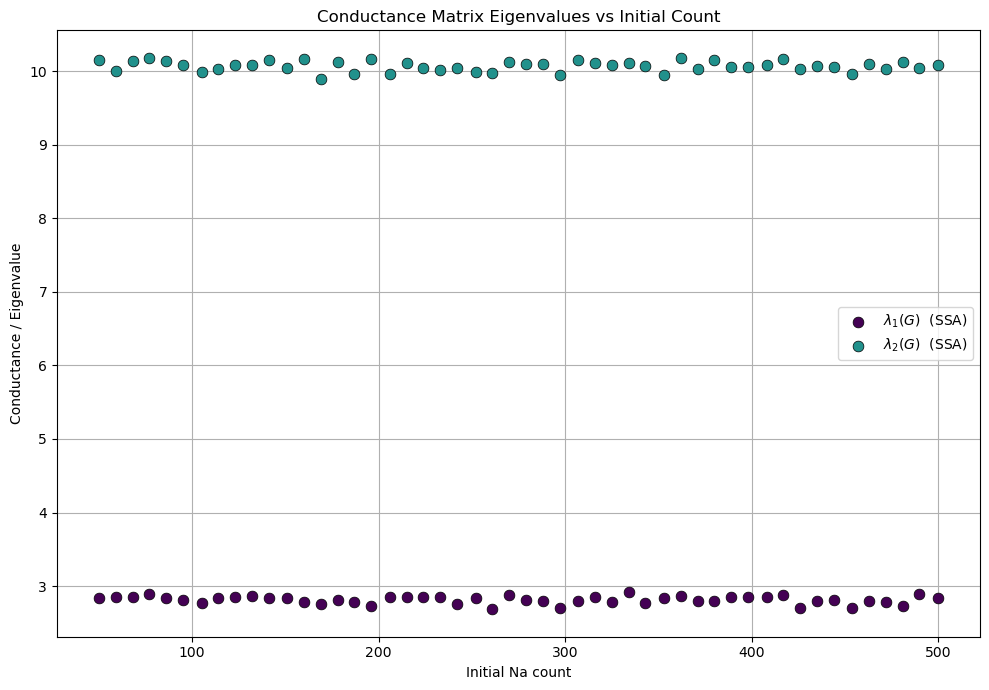

In [14]:
# Compute the conductance and plot.

SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)

SIM3.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=False,
        show_difference=False
    )

# Plotting Calculated Analytical Data

In [ ]:
# But let's say we want to overlay some analytical data. For module 1, we can solve the steady state equations and calculate the 
# currents and forces as below, then we can pass these into the attribute to get an overlay.

rates = rates
k1f = rates[0]
k1b = rates[1]
k2f = rates[2]
k2b = rates[3]
k3f = rates[4]
k3b = rates[5]

S = 50

E_T = 350*3 #initial_counts[0] + initial_counts[1] + initial_counts[2] # total internal species (shouldn't change due to conservation)

analytical_current1 = []
analytical_force1 = []

analytical_current2 = []
analytical_force2 = []

analytical_current3 = []
analytical_force3 = []

Na_counts = np.linspace(50,500,50,dtype='int')

for Na in Na_counts:

    chi = (k2f + k1b)/(k1f*S + k2b*Na)

    j1 = (k1f*k2f*S - k1b*k2b*Na)*E_T / (((k1f*S + k2b*Na)*(1+ k3f*S/k3b))+k2f+k1b)

    f1 = np.log( (k1f*S*(k1b+k2f)) / (k1b*(k1f*S + k2b*Na)) )

    j2 = (E_T *k2f - E_T*k2b*Na*chi)/(1 + chi + k3f*S/k3b )
    
    f2 = np.log( (k2f*(k1f*S + k2b*Na) / (k2b*Na*(k2f + k1b)) ))

    j3 = 0

    f3 = 0

    analytical_current1.append(j1)
    analytical_force1.append(f1)

    analytical_current2.append(j2)
    analytical_force2.append(f2)

    analytical_current3.append(j3)
    analytical_force3.append(f3)

an_currents = [analytical_current1, analytical_current2, analytical_current3]
an_forces = [analytical_force1, analytical_force2, analytical_force3]

In [ ]:
# Now pass these through the calculating attribute and store the result

_, an_conductances = SIM1.compute_conductances(an_currents, an_forces)

# And plot, with an_conductances passed.

SIM1.plot_conductance(
        analytical_G=an_conductances,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )